In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configuración de estilo de gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

# 1. Cargar los datos
df = pd.read_excel('Base_Migracion_2009-2026jun.xlsx')

In [2]:
# Crear una columna de tipo Datetime uniendo 'Año' y 'Mes cod'
# Usamos el día 1 por defecto para representar el periodo mensual entero
df['Fecha'] = pd.to_datetime({
    'year': df['Año'], 
    'month': df['Mes cod'], 
    'day': 1
})

# Limpieza general: descartar si por alguna razón la fecha o la cantidad de viajeros es nula
df = df.dropna(subset=['Fecha', 'Viajero'])

# Asegurarnos de que toda la base de datos esté ordenada cronológicamente
df = df.sort_values('Fecha').reset_index(drop=True)

print(f"Rango total de los datos: {df['Fecha'].min().date()} hasta {df['Fecha'].max().date()}")

Rango total de los datos: 2009-01-01 hasta 2026-06-01


In [3]:
# Extraemos la secuencia de meses únicos ordenados cronológicamente
meses_unicos = df['Fecha'].drop_duplicates().sort_values().reset_index(drop=True)

# Definimos el punto de corte correspondiente al ~70% del tiempo total disponible
indice_corte = int(len(meses_unicos) * 0.7)
fecha_corte = meses_unicos.iloc[indice_corte]

# Aplicamos la máscara temporal para separar los dataframes
df_train = df[df['Fecha'] < fecha_corte].copy()
df_test  = df[df['Fecha'] >= fecha_corte].copy()

print(f"El punto de corte temporal es: {fecha_corte.date()}\n")
print(f"Set de Entrenamiento: abarca {len(df_train['Fecha'].unique())} meses (hasta {df_train['Fecha'].max().date()})")
print(f"Set de Prueba: abarca {len(df_test['Fecha'].unique())} meses (desde {df_test['Fecha'].min().date()})")

El punto de corte temporal es: 2021-04-01

Set de Entrenamiento: abarca 147 meses (hasta 2021-03-01)
Set de Prueba: abarca 63 meses (desde 2021-04-01)


,Viajero
Fecha,
2009-01-01,183505.590535
2009-02-01,149426.253908
2009-03-01,174237.227095
2009-04-01,182842.489917
2009-05-01,133194.667651


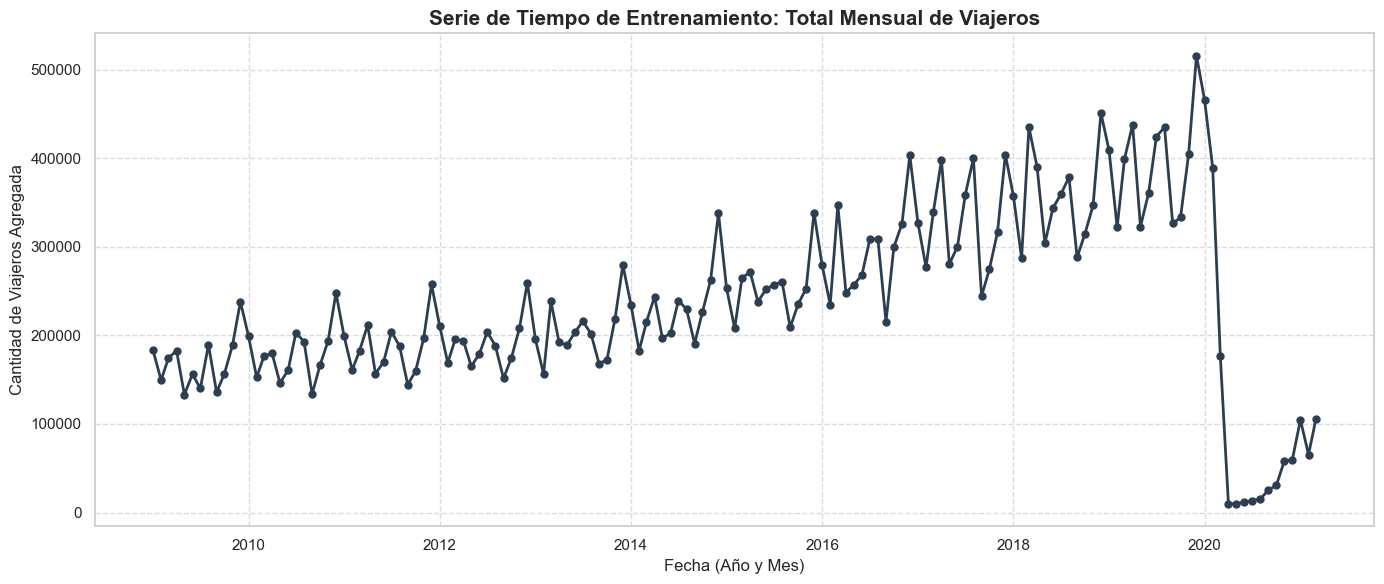

In [4]:
# Agrupamos usando únicamente los datos de entrenamiento
serie_viajeros_train = df_train.groupby('Fecha')['Viajero'].sum().reset_index()

# Al establecer la Fecha como índice, habilitamos herramientas analíticas y de modelos predictivos
serie_viajeros_train.set_index('Fecha', inplace=True)

# Asignamos frecuencia mensual ('MS' = Month Start) formal al índice
serie_viajeros_train.index.freq = 'MS'

display(serie_viajeros_train.head())

# Graficamos el resultado
plt.figure(figsize=(14, 6))
plt.plot(serie_viajeros_train.index, serie_viajeros_train['Viajero'], 
         marker='o', linestyle='-', color='#2c3e50', linewidth=2, markersize=5)
plt.title('Serie de Tiempo de Entrenamiento: Total Mensual de Viajeros', fontsize=15, fontweight='bold')
plt.xlabel('Fecha (Año y Mes)', fontsize=12)
plt.ylabel('Cantidad de Viajeros Agregada', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()